In [1]:
import requests
import pandas as pd
import time
from tqdm import tqdm
import re
import spacy
import numpy as np
from spacy.matcher import PhraseMatcher

## Data Acquisition

In [2]:
API_KEY = "84287db0-182f-4d1b-9d8e-3c2047664fe4"

In [3]:
BASE_URL = "https://content.guardianapis.com/search"

params = {
    "api-key": API_KEY,
    "section": "business",
    "from-date": "2019-01-01",
    "to-date": "2024-12-31",
    "show-fields": "bodyText,headline,byline",
    "show-tags": "type,keyword,tone",
    "page-size": 50,   # maximum allowed
    "page": 1
}

In [4]:
response = requests.get(BASE_URL, params=params)

print("Status code:", response.status_code)
print(response.url)

data = response.json()

Status code: 200
https://content.guardianapis.com/search?api-key=84287db0-182f-4d1b-9d8e-3c2047664fe4&section=business&from-date=2019-01-01&to-date=2024-12-31&show-fields=bodyText%2Cheadline%2Cbyline&show-tags=type%2Ckeyword%2Ctone&page-size=50&page=1


In [5]:
all_articles = []

# First request to get total pages
response = requests.get(BASE_URL, params=params)
data = response.json()

total_pages = data["response"]["pages"]
print(f"Total pages in 2019-2024 in business section: {total_pages}")

for page in tqdm(range(1, total_pages + 1)):
    params["page"] = page
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    articles = data["response"]["results"]
    
    for article in articles:
        fields = article.get("fields", {})
        
        all_articles.append({
            "webTitle": article.get("webTitle"),
            "sectionName": article.get("sectionName"),
            "webPublicationDate": article.get("webPublicationDate"),
            "headline": fields.get("headline"),
            "byline": fields.get("byline"),
            "bodyText": fields.get("bodyText"),
            "tags": article.get("tags"),
            "webUrl": article.get("webUrl")
        })
    
    time.sleep(1)

Total pages in 2019-2024 in business section: 461


100%|████████████████████████████████████████████████████████████████████████████████| 461/461 [09:44<00:00,  1.27s/it]


In [6]:
df = pd.DataFrame(all_articles)

print("Total articles pulled:", len(df))

Total articles pulled: 23027


In [7]:
df.head()

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
0,Great Guinness heist: thieves stole truck carr...,Business,2024-12-31T18:18:27Z,Great Guinness heist: thieves stole truck carr...,Rob Davies and Helena Horton,"In the days leading up to Christmas, stout-lov...","[{'id': 'business/hospitality-industry', 'type...",https://www.theguardian.com/business/2024/dec/...
1,FTSE 100 rallies by 5.7% in 2024 in ‘a year of...,Business,2024-12-31T16:25:35Z,FTSE 100 rallies by 5.7% in 2024 in ‘a year of...,Graeme Wearden,A late PS: The three major U.S. stock indices ...,"[{'id': 'business/business', 'type': 'keyword'...",https://www.theguardian.com/business/live/2024...
2,Russia winds down gas supply to Europe via Ukr...,Business,2024-12-31T15:18:52Z,Russia winds down gas supply to Europe via Ukr...,Jillian Ambrose Energy correspondent,Europe will receive the last Russian gas sent ...,"[{'id': 'business/gas', 'type': 'keyword', 'se...",https://www.theguardian.com/business/2024/dec/...
3,FTSE records strongest annual gain since 2021 ...,Business,2024-12-31T15:16:25Z,FTSE records strongest annual gain since 2021 ...,Graeme Wearden,The UK’s blue-chip stock index has recorded it...,"[{'id': 'business/ftse', 'type': 'keyword', 's...",https://www.theguardian.com/business/2024/dec/...
4,Green light: the boss of GB Railfreight with a...,Business,2024-12-31T13:00:46Z,Green light: the boss of GB Railfreight with a...,Jack Simpson,"Travel north on the east coast mainline, the m...","[{'id': 'business/rail-industry', 'type': 'key...",https://www.theguardian.com/business/2024/dec/...


In [8]:
row = df.iloc[0]

for col in df.columns:
    print(f"{col}: {row[col]}")

webTitle: Great Guinness heist: thieves stole truck carrying 35,000 pints
sectionName: Business
webPublicationDate: 2024-12-31T18:18:27Z
headline: Great Guinness heist: thieves stole truck carrying 35,000 pints
byline: Rob Davies and Helena Horton
bodyText: In the days leading up to Christmas, stout-lovers were left reeling from a nationwide shortage of Guinness so severe that some pubs were forced to ration pints of the “black stuff” as taps began to run dry. Supermarkets remain at risk of running out due to customers’ stockpiling, according to reports, while the maker of the popular stout, Diageo, has even sent for back-up Guinness reserves from Ireland. Now it can be revealed that criminals appear to have gone to even greater lengths to beat the drought, with a heist that exacerbated the nationwide shortage. A truck carrying 400 50-litre kegs of the Irish stout – equivalent to 35,200 pints – disappeared from a depot in the Midlands in mid-December, the Guardian can reveal. It is und

## Exploratory Data Analysis (EDA)

In [9]:
df.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
count,23027,23027,23027,23027,22871,23027,23027,23027
unique,23011,1,22596,23011,2176,23023,22113,23027
top,UK inflation: which goods and services have ch...,Business,2019-06-26T16:00:19Z,UK inflation: which goods and services have ch...,Sarah Butler,,"[{'id': 'business/retail', 'type': 'keyword', ...",https://www.theguardian.com/business/2019/jan/...
freq,9,23027,5,9,1416,5,48,1


In [10]:
print("Total Authors:", df["byline"].nunique())

Total Authors: 2176


In [11]:
print("Most Frequent Authors")
print(df["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Sarah Butler                                  1416
Jasper Jolly                                  1235
Graeme Wearden                                1116
Julia Kollewe                                  984
Nils Pratley                                   915
Phillip Inman                                  846
Mark Sweney                                    845
Richard Partington Economics correspondent     785
Kalyeena Makortoff Banking correspondent       658
Rob Davies                                     621
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Zoe Wood City reporter                                 1
Sarah Boseley and Rob Davies                           1
Larry Elliott, Richard Partington and Jasper Jolly     1
Sarah Butler and Press Association                     1
Sam Levin in Windsor, California                       1
Hannah Ellis-Petersen South east Asia correspondent    1
Katharine Murphy and Lisa Cox                  

In [12]:
len(df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts())

1261

In [13]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().head(5)

byline
Guardian staff and agencies                            56
Elias Visontay Transport and urban affairs reporter    52
Jasper Jolly and agencies                              38
Guardian staff and agency                              30
Staff and agencies                                     26
Name: count, dtype: int64

In [14]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().tail(5)

byline
Jasper Jolly and Justin McCurry in Tokyo    1
Sarah Butler and Angela Monaghan            1
Dominic Rushe and Phillip Inman             1
Sarah Boseley and Rob Davies                1
Joanna Partridge  and Gwyn Topham           1
Name: count, dtype: int64

In [15]:
df["byline"].isna().sum()

np.int64(156)

In [16]:
(df["byline"] == "").sum()

np.int64(76)

In [17]:
df["year"] = pd.to_datetime(df["webPublicationDate"]).dt.year

author_by_year = df.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    484
2020    545
2021    554
2022    626
2023    594
2024    555
Name: byline, dtype: int64


In [18]:
df.groupby("year").size()

year
2019    3606
2020    4244
2021    3989
2022    4070
2023    3655
2024    3463
dtype: int64

In [48]:
df.to_csv("guardian_business_raw.csv", index=False)

# DATA CLEANING

In [31]:
## PARAMETERS
author_min_freq = int(0.001 * len(df)) # Approximately holds atleast 1% of the sample

In [32]:
def clean_authors(df, min_freq=5):
    df = df.copy()
    
    # Remove nulls
    df = df[df["byline"].notna()]
    
    # Remove empty or whitespace-only strings
    df = df[df["byline"].str.strip() != ""]
    
    # Compute author frequencies
    author_counts = df["byline"].value_counts()
    
    # Keep only authors with freq >= min_freq
    valid_authors = author_counts[author_counts >= min_freq].index
    
    df = df[df["byline"].isin(valid_authors)]
    
    return df

In [49]:
df_filtered = clean_authors(df, author_min_freq)

print("Before:", len(df))
print("After:", len(df_filtered))

Before: 23027
After: 18149


In [50]:
print("Most Frequent Authors")
print(df_filtered["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df_filtered["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Sarah Butler                                  1416
Jasper Jolly                                  1235
Graeme Wearden                                1116
Julia Kollewe                                  984
Nils Pratley                                   915
Phillip Inman                                  846
Mark Sweney                                    845
Richard Partington Economics correspondent     785
Kalyeena Makortoff Banking correspondent       658
Rob Davies                                     621
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Helena Horton Environment reporter           26
Staff and agencies                           26
Katharine Murphy Political editor            26
Jonathan Barrett Senior business reporter    26
Amy Remeikis                                 26
Lauren Aratani in New York                   25
Jedidajah Otte                               25
Robert Booth Social affairs correspondent    24
Naama

In [51]:
def has_tone(tag_list, tone_id):
    if not isinstance(tag_list, list):
        return False
    return any(tag.get("id") == tone_id for tag in tag_list)

def has_type(tag_list, type_id):
    if not isinstance(tag_list, list):
        return False
    return any(tag.get("id") == type_id for tag in tag_list)

In [52]:
# Removing unwanted tones
df_filtered = df_filtered[
    ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/minutebyminute")) &
    ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/comment"))
]

In [53]:
# Keeping only type/articles
df_filtered = df_filtered[
    df_filtered["tags"].apply(lambda x: has_type(x, "type/article"))
]

In [54]:
# Removing /live/ urls
df_filtered = df_filtered[
    ~df_filtered["webUrl"].str.contains("/live/", na=False)
]

In [55]:
df_clean = df_filtered.copy()

In [56]:
df_clean["year"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.year

author_by_year = df_clean.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    54
2020    57
2021    59
2022    62
2023    68
2024    62
Name: byline, dtype: int64


In [57]:
df_clean.groupby("year").size()

year
2019    2153
2020    2705
2021    2510
2022    2599
2023    2345
2024    2125
dtype: int64

In [58]:
clean_counts = df_clean.groupby("year").size()
raw_counts = df.groupby("year").size()

difference = raw_counts - clean_counts
print(difference)

year
2019    1453
2020    1539
2021    1479
2022    1471
2023    1310
2024    1338
dtype: int64


In [59]:
df_clean["month"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.month
df_clean["day"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.day
df_clean["date"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.tz_localize(None)
df_clean["tm"] = (
    (df_clean["date"] - pd.Timestamp("2019-01-01"))
    .dt.days / 30
)

In [60]:
df_clean["post"] = (df_clean["date"] >= "2022-11-01").astype(int)

In [61]:
df_clean.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl,year,month,day,date,tm,post
count,14437,14437,14437,14437,14437,14437,14437,14437,14437.000000,14437.000000,14437.000000,14437,14437.000000,14437.000000
unique,14424,1,14203,14424,78,14437,14002,14437,NaN,NaN,NaN,NaN,NaN,NaN
top,UK inflation: which goods and services have ch...,Business,2019-06-26T16:00:19Z,UK inflation: which goods and services have ch...,Sarah Butler,Britain’s biggest listed companies will be for...,"[{'id': 'business/retail', 'type': 'keyword', ...",https://www.theguardian.com/business/2019/jan/...,NaN,NaN,NaN,NaN,NaN,NaN
freq,8,14437,4,8,1416,1,44,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.460830,6.471843,15.630602,2021-12-15 22:42:40.709011712,35.980072,0.337674
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,1.000000,1.000000,2019-01-01 00:01:06,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,3.000000,8.000000,2020-07-05 23:01:56,18.366667,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,6.000000,16.000000,2021-12-09 19:30:07,35.766667,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,9.000000,23.000000,2023-05-04 08:19:13,52.800000,1.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,12.000000,31.000000,2024-12-31 15:18:52,73.033333,1.000000


In [62]:
row = df_clean.iloc[0]

for col in df_clean.columns:
    print(f"{col}: {row[col]}")

webTitle: Russia winds down gas supply to Europe via Ukraine as transit deal expires
sectionName: Business
webPublicationDate: 2024-12-31T15:18:52Z
headline: Russia winds down gas supply to Europe via Ukraine as transit deal expires
byline: Jillian Ambrose Energy correspondent
bodyText: Europe will receive the last Russian gas sent via Ukraine’s pipelines in the early hours of the new year as the continent braces for a plunge in temperatures that could hasten the drain on gas reserves. The Russian state energy company, Gazprom, is expected to cut off its exports to Europe through Ukraine’s pipelines on New Year’s Day after a gas transit deal struck between the countries five years ago comes to an end overnight. In the absence of an 11th-hour deal, the halt will mark a historic shift after the Kremlin’s full-scale invasion of its neighbour in early 2022. Russia was once the continent’s biggest supplier of gas but it has lost almost all of its EU customers since the war began, as buyers 

In [47]:
df_clean.to_csv("guardian_business_clean.csv", index=False)

## DATA PREPROCESSING

In [63]:
df_clean = pd.read_csv("guardian_business_clean.csv")
# Restore datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

In [64]:
def clean_text(text):
    if pd.isna(text):
        return None
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    # Fix HTML entities like &amp;
    text = text.replace("&amp;", "&")
    
    return text.strip()

df_clean["clean_text"] = df_clean["bodyText"].apply(clean_text)

In [65]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

docs = list(nlp.pipe(df_clean["clean_text"], batch_size=50))

In [66]:
HEDGE_TOKENS = {
    "may","might","could","would","should","can",
    "likely","unlikely","possibly","perhaps","potentially","apparently","arguably",
    "seem","seems","seemed","seeming",
    "appear","appears","appeared","appearing",
    "suggest","suggests","suggested","suggesting",
    "estimate","estimates","estimated","estimating",
    "indicate","indicates","indicated","indicating",
    "roughly","about","around","approximately"
}

In [67]:
hedge_counts = []
n_sentences = []
word_counts = []
avg_sentence_lengths = []
burstiness_scores = []

for doc in docs:
    
    sentences = list(doc.sents)
    sentence_lengths = []
    hedge_count = 0
    
    for sent in sentences:
        length = 0
        for token in sent:
            if token.is_space or token.is_punct:
                continue
            
            length += 1
            
            # Hedge detection using lemma (cleaner than raw text)
            if token.lemma_.lower() in HEDGE_TOKENS:
                hedge_count += 1
        
        sentence_lengths.append(length)
    
    n_sent = len(sentence_lengths)
    total_words = sum(sentence_lengths)
    
    n_sentences.append(n_sent)
    word_counts.append(total_words)
    hedge_counts.append(hedge_count)
    
    if n_sent > 0:
        avg_len = total_words / n_sent
        avg_sentence_lengths.append(avg_len)
        
        if avg_len > 0:
            burstiness_scores.append(np.std(sentence_lengths) / avg_len)
        else:
            burstiness_scores.append(np.nan)
    else:
        avg_sentence_lengths.append(np.nan)
        burstiness_scores.append(np.nan)

In [68]:
df_clean["n_sentences"] = n_sentences
df_clean["word_count"] = word_counts
df_clean["avg_sentence_length"] = avg_sentence_lengths
df_clean["burstiness"] = burstiness_scores
df_clean["hedge_count"] = hedge_counts
df_clean["hedge_rate"] = df_clean["hedge_count"] / df_clean["word_count"]

In [69]:
df_clean[[
    "word_count",
    "n_sentences",
    "avg_sentence_length",
    "burstiness"
]].describe()

,word_count,n_sentences,avg_sentence_length,burstiness
count,14437.000000,14437.000000,14437.000000,14437.000000
mean,610.633442,23.642377,26.661518,0.398788
std,249.628464,11.548765,4.138532,0.098651
min,58.000000,2.000000,9.125000,0.091390
25%,449.000000,16.000000,24.095238,0.334365
50%,561.000000,21.000000,26.600000,0.390528
75%,705.000000,27.000000,29.150000,0.451326
max,3469.000000,144.000000,97.800000,1.759458


<Axes: xlabel='year,month'>

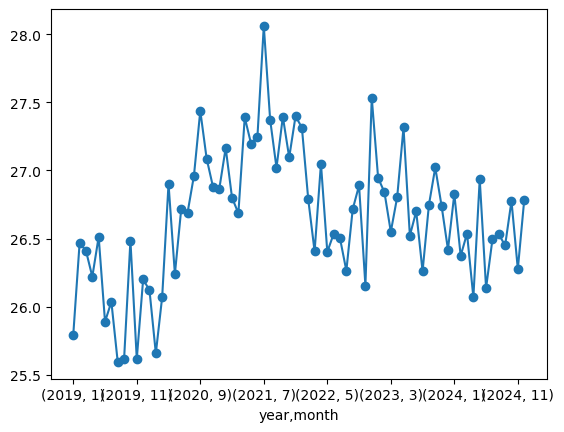

In [70]:
df_clean.groupby(["year", "month"])["avg_sentence_length"].mean().plot(marker="o")

<Axes: xlabel='year,month'>

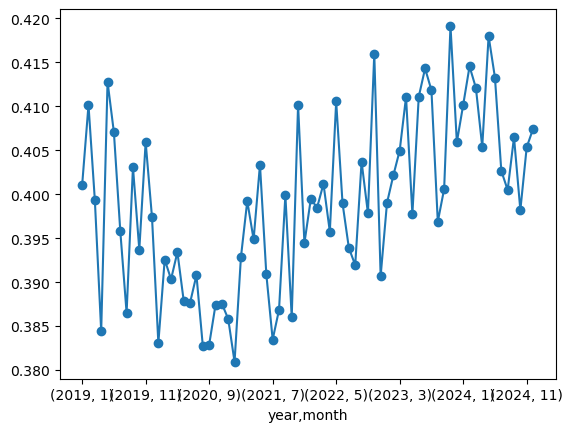

In [71]:
df_clean.groupby(["year", "month"])["burstiness"].mean().plot(marker="o")

<Axes: xlabel='year'>

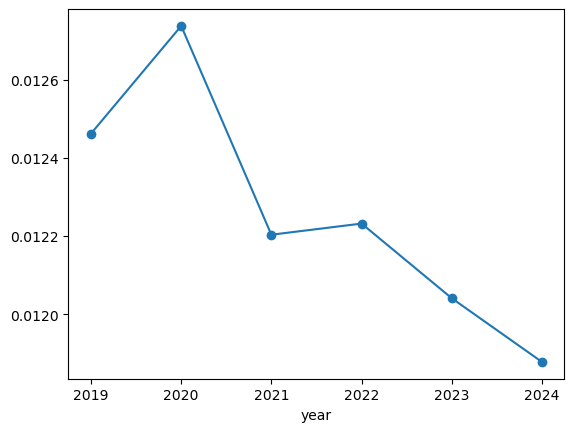

In [72]:
df_clean.groupby("year")["hedge_rate"].mean().plot(marker="o")

In [73]:
df_clean.to_csv("post_processing_business.csv", index=False)